In [ ]:
#Imports
import pandas as pd
import matplotlib.pyplot as plt
from ipumspy import readers
import pandas as pd
import os

In [ ]:
# Random 3M-record IPUMS load (reproducible sampling)
import gzip
import os
import random
from ipumspy import readers

# Define file paths
ddi_file_path = r"C:\Users\linds\OneDrive\Documents\Unidos\acs_1.xml"
data_file_path = r"C:\Users\linds\OneDrive\Documents\Unidos\acs_1.dat.gz"

# Sampling settings
n_records = 3_000_000
sample_seed = 15211
rng = random.Random(sample_seed)

print(f"DDI file exists: {os.path.exists(ddi_file_path)}")
print(f"Data file exists: {os.path.exists(data_file_path)}")
if os.path.exists(data_file_path):
    print(f"Data file size: {os.path.getsize(data_file_path) / (1024**3):.2f} GB")

# Pass 1: count total records in source file
print("Counting total records in source file...")
with gzip.open(data_file_path, 'rt', encoding='utf-8', newline='') as fin:
    total_records = sum(1 for _ in fin)

if total_records == 0:
    raise ValueError("Source file has 0 records.")

if n_records > total_records:
    print(f"Requested {n_records:,} records but file has {total_records:,}. Using full file size instead.")
    n_records = total_records

print(f"Selecting {n_records:,} random records (seed={sample_seed}) from {total_records:,} total...")
selected_indices = sorted(rng.sample(range(total_records), n_records))

chunk_file_path = data_file_path.replace(
    '.dat.gz',
    f'_random_chunk_{n_records}_seed{sample_seed}.dat.gz'
)

# Pass 2: write sampled records to a smaller gz file
with gzip.open(data_file_path, 'rt', encoding='utf-8', newline='') as fin, \
     gzip.open(chunk_file_path, 'wt', encoding='utf-8', newline='') as fout:
    selected_ptr = 0
    selected_len = len(selected_indices)

    for i, line in enumerate(fin):
        if selected_ptr >= selected_len:
            break
        if i == selected_indices[selected_ptr]:
            fout.write(line)
            selected_ptr += 1

print(f"Random chunk created: {chunk_file_path}")
print(f"Chunk size: {os.path.getsize(chunk_file_path) / (1024**2):.1f} MB")

# Read chunk into DataFrame
print("Reading DDI codebook...")
ddi_codebook = readers.read_ipums_ddi(ddi_file_path)

print("Reading random microdata chunk...")
ipums_df = readers.read_microdata(ddi_codebook, chunk_file_path)

print(f"\nRandom chunk DataFrame shape: {ipums_df.shape}")
print(ipums_df.head())

DDI file exists: True
Data file exists: True
Data file size: 0.41 GB
Counting total records in source file...
Selecting 3,000,000 random records (seed=15211) from 15,912,393 total...
Random chunk created: C:\Users\linds\OneDrive\Documents\Unidos\acs_1_random_chunk_3000000_seed15211.dat.gz
Chunk size: 86.7 MB
Reading DDI codebook...
Reading random microdata chunk...


c:\Users\linds\repos\Unidos\venv\Lib\site-packages\ipumspy\readers.py:70: CitationWarning: Use of data from IPUMS is subject to conditions including that users should cite the data appropriately.
See the `ipums_conditions` attribute of this codebook for terms of use.
See the `ipums_citation` attribute of this codebook for the appropriate citation.
  warnings.warn(



Random chunk DataFrame shape: (3000000, 57)
   YEAR  MULTYEAR  SAMPLE  SERIAL       CBSERIAL  HHWT        CLUSTER  \
0  2023      2019  202303       3  2019010000153   4.0  2023000000033   
1  2023      2019  202303       4  2019010000198  17.0  2023000000043   
2  2023      2019  202303       8  2019010000284   3.0  2023000000083   
3  2023      2019  202303      17  2019010000742  16.0  2023000000173   
4  2023      2019  202303      20  2019010000950   1.0  2023000000203   

   STATEICP  STATEFIP  COUNTYICP  ...  OCCSOC  INDNAICS  INCSS  INCWELFR  \
0        41         1        150  ...  434051      8131      0         0   
1        41         1        150  ...       0         0  26783         0   
2        41         1          0  ...       0         0      0         0   
3        41         1          0  ...       0         0      0         0   
4        41         1          0  ...       0         0      0         0   

   INCSUPP  MIGRATE1  MIGRATE1D  VETSTAT  VETSTATD  QEDUC  

# Follow the Borjas Methodology for Calculating Likely Unauthorized Immigrants

Note: Full sample size for (2024-2025) 159,301; in Borjas paper (2012-2013 comparison file), full sample size is 191,768.

In [ ]:
#Sample Restrictions
#Drop all except ages 20-64.
ipums_df = ipums_df[ipums_df['AGE'].between(20, 64, inclusive='both')]

Step 1: Restrict to Foreign-Born Population

In [ ]:
#ACS vs CPS
foreign_born_df = ipums_df[pd.to_numeric(ipums_df.get('BPL'), errors='coerce') >= 150]

Step 2: Assign "likely legal" if someone immigrated before 1980, or was born in Cuba and immigrated before 2017.

In [ ]:
#ACS
foreign_born_df['likely_legal'] = foreign_born_df['YRIMMIG'] <= 1980


C:\Users\linds\AppData\Local\Temp\ipykernel_58772\283586698.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['likely_legal'] = foreign_born_df['YRIMMIG'] <= 1980


Step 3: Assign likely legal if receiving public benefits, such as social security income.

In [ ]:
#ACS
foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('INCSS', pd.Series(0, index=foreign_born_df.index)), errors='coerce').fillna(0) > 0)
foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('INCSUP', pd.Series(0, index=foreign_born_df.index)), errors='coerce').fillna(0) > 0)
foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('INCWELFR', pd.Series(0, index=foreign_born_df.index)), errors='coerce').fillna(0) > 0)

C:\Users\linds\AppData\Local\Temp\ipykernel_58772\2260069458.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('INCSS', pd.Series(0, index=foreign_born_df.index)), errors='coerce').fillna(0) > 0)
C:\Users\linds\AppData\Local\Temp\ipykernel_58772\2260069458.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df

Step 4: Assign likely legal if receiving public housing assistance.

Step 5: Assign likely legal if they are a veteran.

In [ ]:
#Step 5: Update to legal if veteran
#update to 7,035
foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('VETSTAT', 0), errors='coerce') == 2)



C:\Users\linds\AppData\Local\Temp\ipykernel_58772\2531878536.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('VETSTAT', 0), errors='coerce') == 2)


Step 6: Assign likely legal if receiving Medicaid or Medicare.

In [ ]:
foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('HINSCAID', 0), errors='coerce') ==2)
foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('HINSCARE', 0), errors='coerce') ==2)


C:\Users\linds\AppData\Local\Temp\ipykernel_58772\583396143.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('HINSCAID', 0), errors='coerce') ==2)
C:\Users\linds\AppData\Local\Temp\ipykernel_58772\583396143.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('HINSCARE', 0), errors='coerce') ==2)


Sstep 7: Assign likely legal if their status is reported as a citizen.

In [ ]:
#ACS
foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('CITIZEN', 0), errors='coerce') <=2)


C:\Users\linds\AppData\Local\Temp\ipykernel_58772\339092554.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('CITIZEN', 0), errors='coerce') <=2)


Step 8: Assign likely legal if they are a federal employee.

In [ ]:
foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('CLASSWKR', 0), errors='coerce') ==25)
foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('CLASSWKR', 0), errors='coerce') ==26)
foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('CLASSWKR', 0), errors='coerce') ==27)
foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('CLASSWKR', 0), errors='coerce') ==28)


C:\Users\linds\AppData\Local\Temp\ipykernel_58772\3865445322.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('CLASSWKR', 0), errors='coerce') ==25)
C:\Users\linds\AppData\Local\Temp\ipykernel_58772\3865445322.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('CLASSWKR', 0), errors='coerce') ==26)
C:

Step 9: Assign likely legal if they are in fields requiring licenses, following Borjas definitions.

In [ ]:
#step 9: OCC is licensed/regulated groups
occ_numeric = pd.to_numeric(foreign_born_df.get('OCC', 0), errors='coerce').fillna(0)
in_range = (
    ((occ_numeric >= 2200) & (occ_numeric <= 3540)) |  # Healthcare Practitioners
    ((occ_numeric >= 3700) & (occ_numeric <= 3950)) |  # Protective Service
    ((occ_numeric >= 2100) & (occ_numeric <= 2160)) |  # Legal
    ((occ_numeric >= 2300) & (occ_numeric <= 2550)) |  # Education
    ((occ_numeric >= 9030) & (occ_numeric <= 9040)) |  # Aviation/Transport
    ((occ_numeric >= 1300) & (occ_numeric <= 1560))    # Engineering/Arch
)
foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | in_range

#11,882 (34%)

C:\Users\linds\AppData\Local\Temp\ipykernel_58772\2123902115.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | in_range


Step 11: H1B Visa Designation

In [ ]:
# step 11: H1B-related likely legal designation
educ_numeric = pd.to_numeric(foreign_born_df.get('EDUC', 0), errors='coerce').fillna(0)
yrimmig_numeric = pd.to_numeric(foreign_born_df.get('YRIMMIG', foreign_born_df.get('yrimmig', 0)), errors='coerce').fillna(0)

h1b_likely_legal = (educ_numeric >= 10) | (yrimmig_numeric >= 2020)
foreign_born_df.loc[:, 'likely_legal'] = foreign_born_df['likely_legal'] | h1b_likely_legal

# EDUC 111+ or YRIMMIG 56+ marked likely legal

Step 10: Assign likely legal if their spouse (in accordance with above criteria) is assigned as likely legal.

In [ ]:
#step 10: If your spouse (identified by SPLOC) is likely legal, you are too
# Build a dictionary mapping (CPSID, PERNUM) to legal status
legal_map = {}
for idx, row in foreign_born_df.iterrows():
    legal_map[(row['CBSERIAL'], row['PERNUM'])] = row['likely_legal']

# Check if spouse is legal
def is_spouse_legal(row):
    if pd.isna(row['SPLOC']) or row['SPLOC'] == 0:
        return False
    return legal_map.get((row['CBSERIAL'], row['SPLOC']), False)

foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | foreign_born_df.apply(is_spouse_legal, axis=1)

#10,363 (30%) vs (32%)

C:\Users\linds\AppData\Local\Temp\ipykernel_58772\4163549747.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | foreign_born_df.apply(is_spouse_legal, axis=1)


# Occupational Distribution of "Likely Legal" vs "Likely Unauthorized"

State of California, to start

In [ ]:
# Create industry description mapping based on OCC2010 codes
industry_ranges = [
    (10, 430, "Management in Business, Science, and Arts"),
    (500, 730, "Business Operations Specialists"),
    (800, 950, "Financial Specialists"),
    (1000, 1240, "Computer and Mathematical"),
    (1300, 1540, "Architecture and Engineering"),
    (1550, 1560, "Technicians"),
    (1600, 1980, "Life, Physical, and Social Science"),
    (2000, 2060, "Community and Social Services"),
    (2100, 2150, "Legal"),
    (2200, 2550, "Education, Training, and Library"),
    (2600, 2920, "Arts, Design, Entertainment, Sports, and Media"),
    (3000, 3540, "Healthcare Practitioners and Technicians"),
    (3600, 3650, "Healthcare Support"),
    (3700, 3950, "Protective Service"),
    (4000, 4150, "Food Preparation and Serving"),
    (4200, 4250, "Building and Grounds Cleaning and Maintenance"),
    (4300, 4650, "Personal Care and Service"),
    (4700, 4965, "Sales and Related"),
    (5000, 5940, "Office and Administrative Support"),
    (6005, 6130, "Farming, Fisheries, and Forestry"),
    (6200, 6765, "Construction"),
    (6800, 6940, "Extraction"),
    (7000, 7630, "Installation, Maintenance, and Repair"),
    (7700, 8965, "Production"),
    (9000, 9750, "Transportation and Material Moving"),
    (9800, 9830, "Military"),
    (9920, 9920, "No Industry")
]

def map_industry(occ_code):
    """Map OCC2010 code to industry description."""
    if pd.isna(occ_code) or occ_code == 0:
        return "Unknown"
    for start, end, desc in industry_ranges:
        if start <= occ_code <= end:
            return desc
    return "Unknown"

foreign_born_df['industry_desc'] = foreign_born_df['OCC2010'].apply(map_industry)

C:\Users\linds\AppData\Local\Temp\ipykernel_58772\2756098945.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['industry_desc'] = foreign_born_df['OCC2010'].apply(map_industry)


All Foreign Born

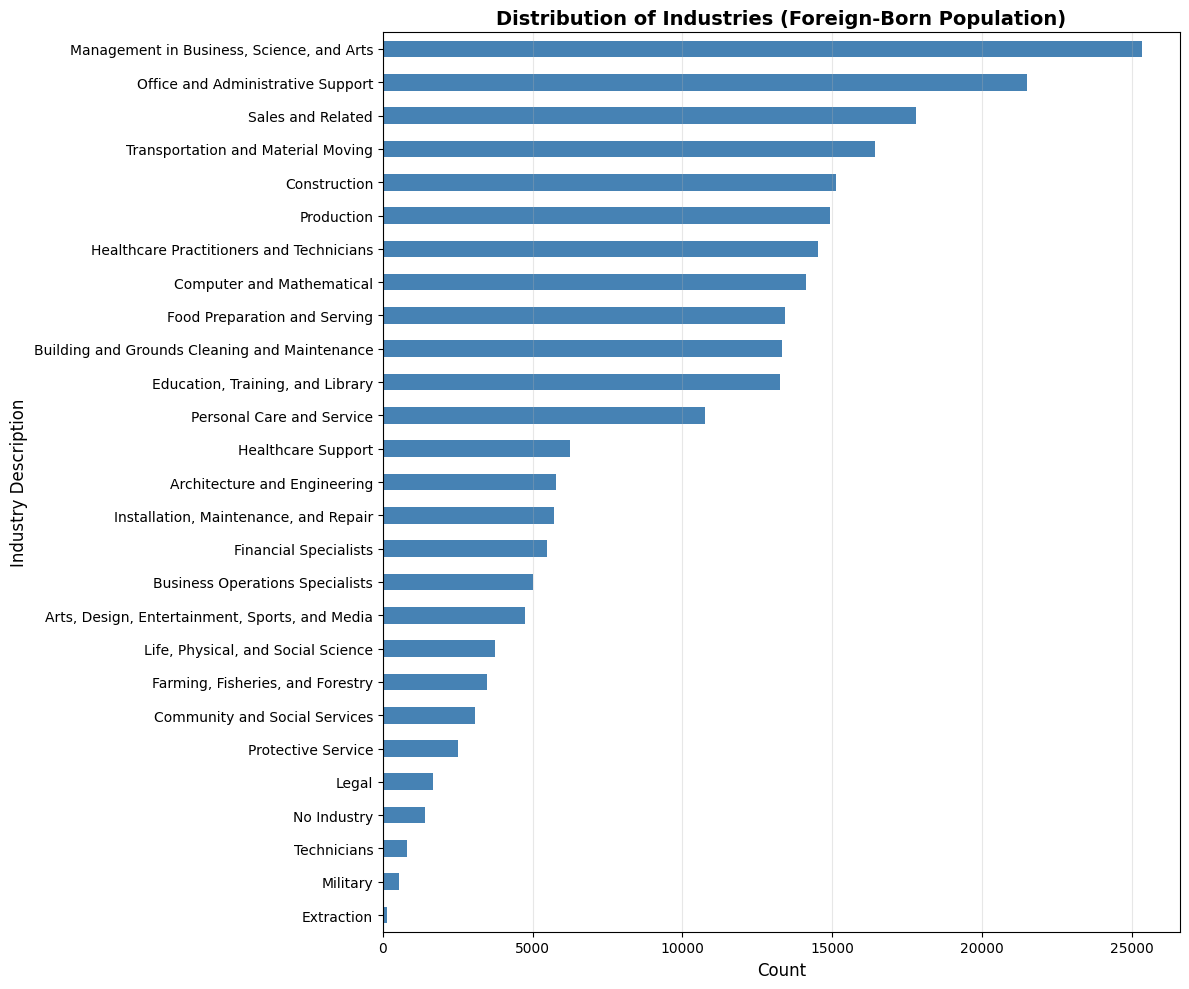


Total records: 281046
Number of industry categories: 27

Top 5 most common industries:
industry_desc
Unknown                                      40144
Management in Business, Science, and Arts    25349
Office and Administrative Support            21495
Sales and Related                            17792
Transportation and Material Moving           16423
Name: count, dtype: int64


In [ ]:
industry_counts = foreign_born_df['industry_desc'].value_counts().sort_values(ascending=True)
industry_counts = industry_counts[industry_counts.index != 'Unknown'].sort_values(ascending=True)
# Create a horizontal bar chart for better readability
fig, ax = plt.subplots(figsize=(12, 10))
industry_counts.plot(kind='barh', ax=ax, color='steelblue')

ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Industry Description', fontsize=12)
ax.set_title('Distribution of Industries (Foreign-Born Population)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nTotal records: {len(foreign_born_df)}")
print(f"Number of industry categories: {len(industry_counts)}")
print(f"\nTop 5 most common industries:")
print(foreign_born_df['industry_desc'].value_counts().head())

Likely Legal

In [ ]:
df_likely_legal = foreign_born_df[foreign_born_df['likely_legal']]

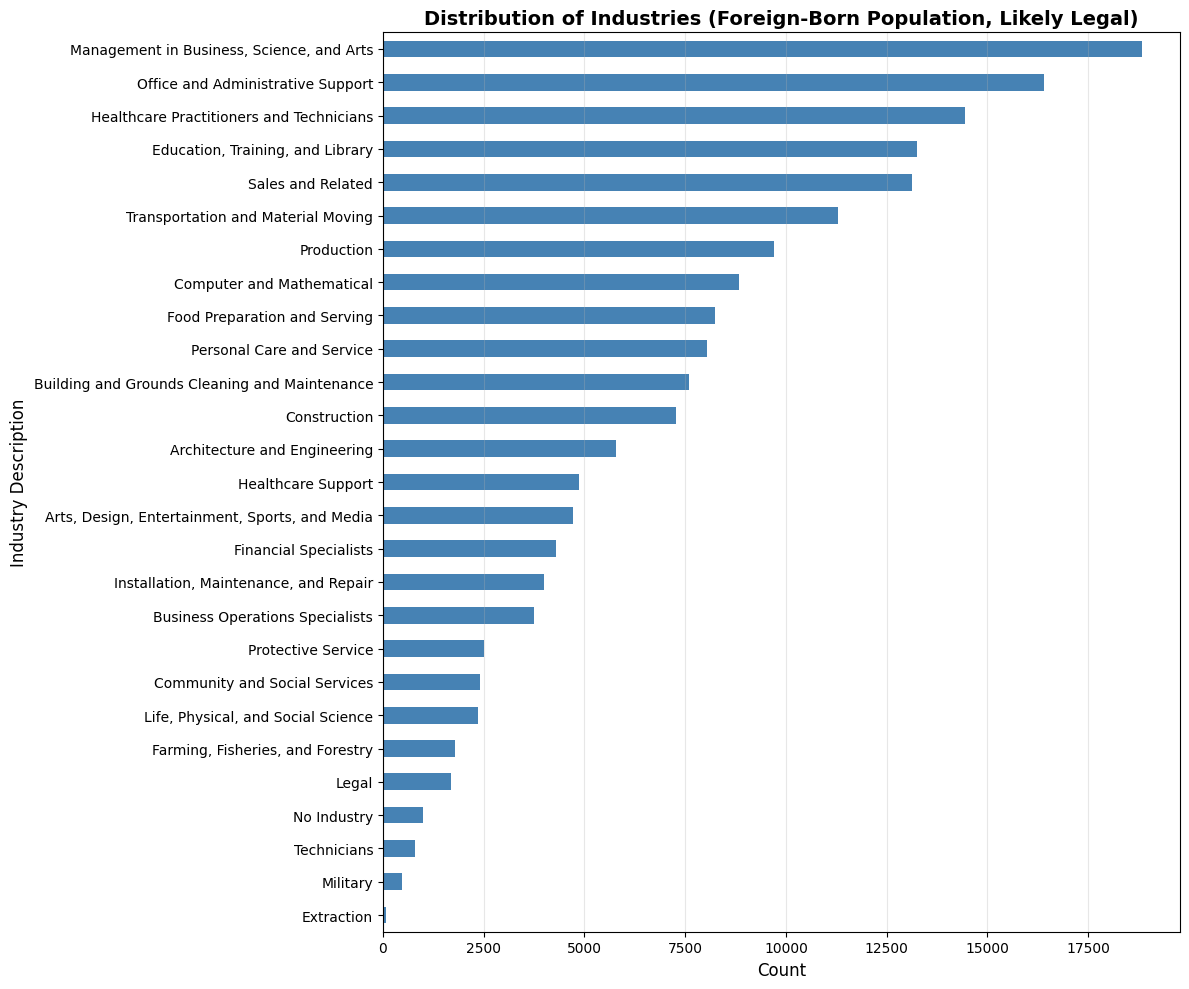


Total records: 205192
Number of industry categories: 27

Top 5 most common industries:
industry_desc
Unknown                                      27635
Management in Business, Science, and Arts    18837
Office and Administrative Support            16404
Healthcare Practitioners and Technicians     14445
Education, Training, and Library             13248
Name: count, dtype: int64


In [ ]:

# Count the distribution of industry descriptions in California
industry_counts = df_likely_legal['industry_desc'].value_counts().sort_values(ascending=True)
industry_counts = industry_counts[industry_counts.index != 'Unknown'].sort_values(ascending=True)

# Create a horizontal bar chart for better readability
fig, ax = plt.subplots(figsize=(12, 10))
industry_counts.plot(kind='barh', ax=ax, color='steelblue')

ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Industry Description', fontsize=12)
ax.set_title('Distribution of Industries (Foreign-Born Population, Likely Legal)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nTotal records: {len(df_likely_legal)}")
print(f"Number of industry categories: {len(industry_counts)}")
print(f"\nTop 5 most common industries:")
print(df_likely_legal['industry_desc'].value_counts().head())

Likely Unauthorized

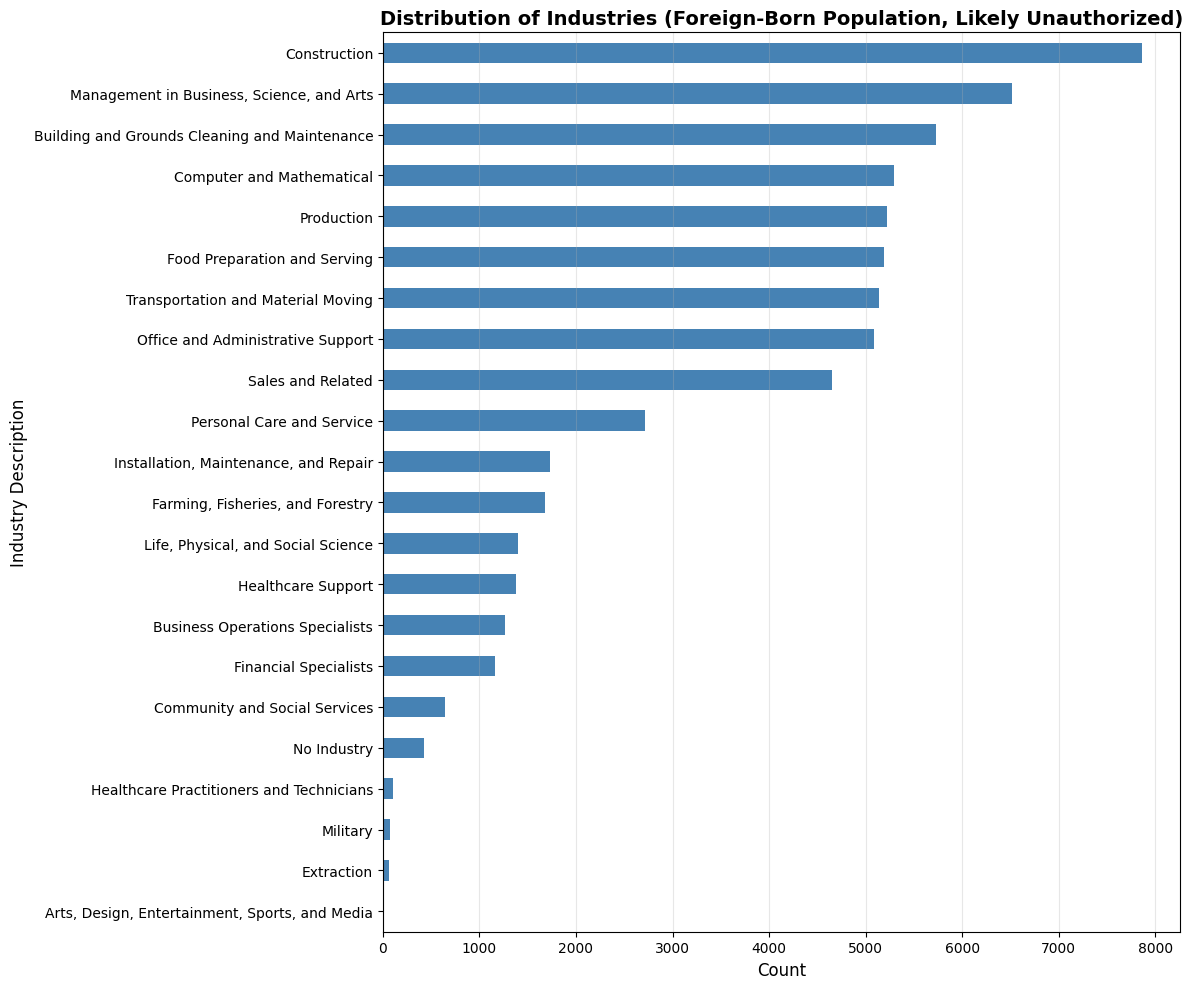


Total records: 75854
Number of industry categories: 22

Top 5 most common industries:
industry_desc
Unknown                                          12509
Construction                                      7864
Management in Business, Science, and Arts         6512
Building and Grounds Cleaning and Maintenance     5730
Computer and Mathematical                         5295
Name: count, dtype: int64


In [ ]:
#Create unauthorized df
df_likely_unauthorized = foreign_born_df[~foreign_born_df['likely_legal']]
# Count the distribution of industry descriptions in California
industry_counts = df_likely_unauthorized['industry_desc'].value_counts().sort_values(ascending=True)
industry_counts = industry_counts[industry_counts.index != 'Unknown'].sort_values(ascending=True)

# Create a horizontal bar chart for better readability
fig, ax = plt.subplots(figsize=(12, 10))
industry_counts.plot(kind='barh', ax=ax, color='steelblue')

ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Industry Description', fontsize=12)
ax.set_title('Distribution of Industries (Foreign-Born Population, Likely Unauthorized)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nTotal records: {len(df_likely_unauthorized)}")
print(f"Number of industry categories: {len(industry_counts)}")
print(f"\nTop 5 most common industries:")
print(df_likely_unauthorized['industry_desc'].value_counts().head())

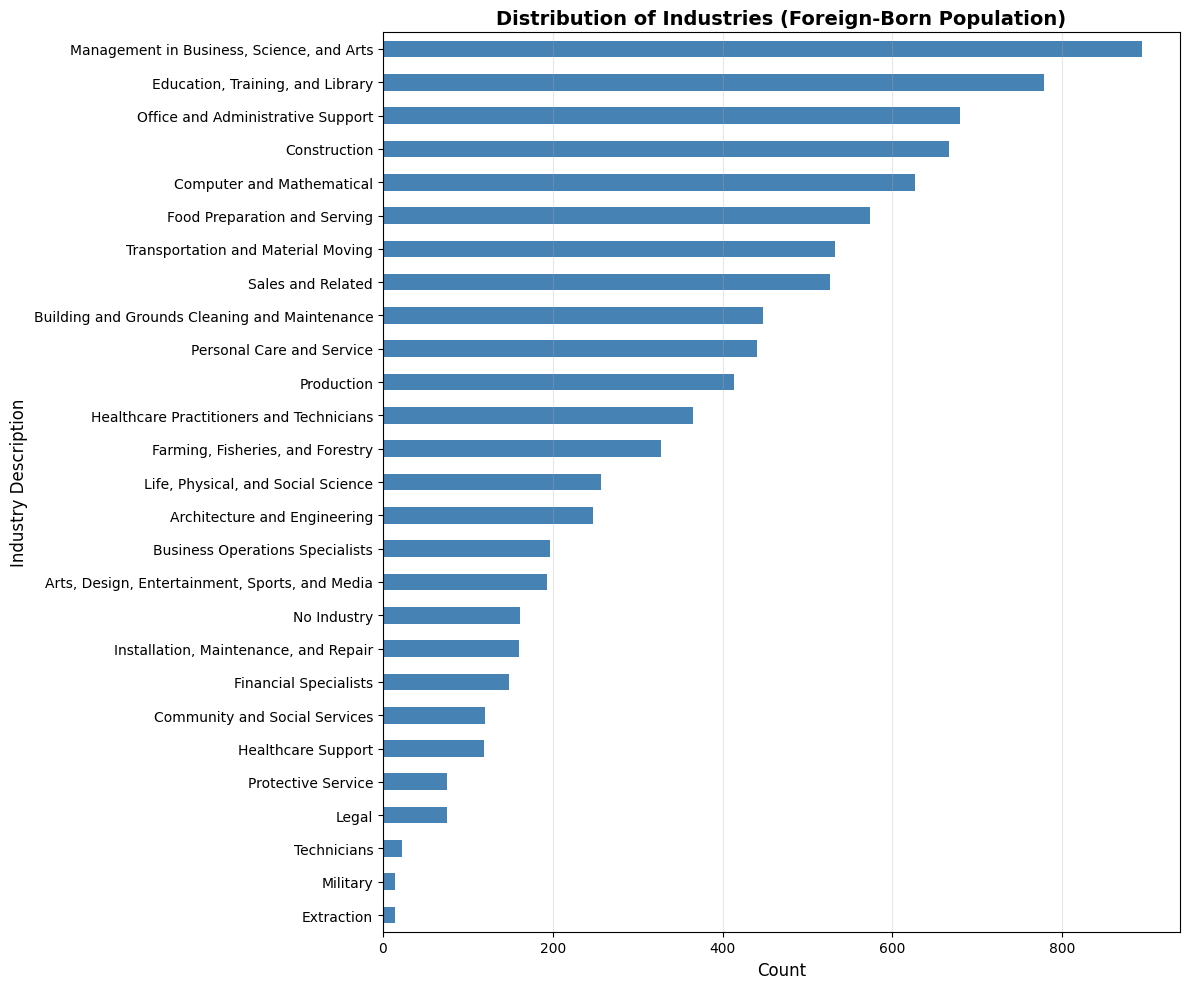


Total records: 11586
Number of industry categories: 27

Top 5 most common industries:
industry_desc
Unknown                                      2511
Management in Business, Science, and Arts     894
Education, Training, and Library              778
Office and Administrative Support             680
Construction                                  667
Name: count, dtype: int64


In [ ]:
df_h1b_likely_legal = foreign_born_df[h1b_likely_legal].copy()

industry_counts = df_h1b_likely_legal['industry_desc'].value_counts().sort_values(ascending=True)
industry_counts = industry_counts[industry_counts.index != 'Unknown'].sort_values(ascending=True)
# Create a horizontal bar chart for better readability
fig, ax = plt.subplots(figsize=(12, 10))
industry_counts.plot(kind='barh', ax=ax, color='steelblue')

ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Industry Description', fontsize=12)
ax.set_title('Distribution of Industries (Foreign-Born Population)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nTotal records: {len(df_h1b_likely_legal)}")
print(f"Number of industry categories: {len(industry_counts)}")
print(f"\nTop 5 most common industries:")
print(df_h1b_likely_legal['industry_desc'].value_counts().head())

# Detailed Occupations

In [ ]:
# Create detailed occupation mapping based on OCC2010 codes with individual labels
detailed_occ_mapping = {
    10: "Chief executives and legislators",
    20: "General and Operations Managers",
    40: "Advertising and Promotions Managers",
    50: "Marketing and Sales Managers",
    60: "Public Relations and Fundraising Managers",
    100: "Administrative Services Managers",
    110: "Computer and Information Systems Managers",
    120: "Financial Managers",
    135: "Compensation and benefits managers",
    136: "Human Resources Managers",
    137: "Training and development managers",
    140: "Industrial Production Managers",
    150: "Purchasing Managers",
    160: "Transportation, Storage, and Distribution Managers",
    205: "Farmers, Ranchers, and Other Agricultural Managers",
    220: "Construction Managers",
    230: "Education Administrators",
    300: "Architectural and Engineering Managers",
    310: "Food Service Managers",
    330: "Gaming Managers",
    340: "Lodging Managers",
    350: "Medical and Health Services Managers",
    360: "Natural Sciences Managers",
    410: "Property, Real Estate, and Community Association Managers",
    420: "Social and Community Service Managers",
    425: "Emergency management directors",
    430: "Miscellaneous managers, including funeral service managers and postmasters and mail superintendents",
    500: "Agents and Business Managers of Artists, Performers, and Athletes",
    510: "Buyers and Purchasing Agents, Farm Products",
    520: "Wholesale and Retail Buyers, Except Farm Products",
    530: "Purchasing Agents, Except Wholesale, Retail, and Farm Products",
    540: "Claims Adjusters, Appraisers, Examiners, and Investigators",
    565: "Compliance Officers",
    600: "Cost Estimators",
    630: "Human Resources Workers",
    640: "Compensation, benefits, and job analysis specialists",
    650: "Training and development specialists",
    700: "Logisticians",
    710: "Management Analysts",
    725: "Meeting, Convention, and Event Planners",
    726: "Fundraisers",
    735: "Market Research Analysts and Marketing Specialists",
    740: "Business Operations Specialists, All Other",
    800: "Accountants and Auditors",
    810: "Appraisers and Assessors of Real Estate",
    820: "Budget Analysts",
    830: "Credit Analysts",
    840: "Financial Analysts",
    850: "Personal Financial Advisors",
    860: "Insurance Underwriters",
    900: "Financial Examiners",
    910: "Credit Counselors and Loan Officers",
    930: "Tax Examiners and Collectors, and Revenue Agents",
    940: "Tax Preparers",
    950: "Financial Specialists, All Other",
    1005: "Computer and information research scientists",
    1006: "Computer Systems Analysts",
    1007: "Information security analysts",
    1010: "Computer Programmers",
    1020: "Software Developers, Applications and Systems Software",
    1030: "Web Developers",
    1050: "Computer Support Specialists",
    1060: "Database Administrators",
    1105: "Network and Computer Systems Administrators",
    1106: "Computer network architects",
    1107: "Computer occupations, all other",
    1200: "Actuaries",
    1220: "Operations Research Analysts",
    1240: "Miscellaneous mathematical science occupations, including mathematicians and statisticians",
    1300: "Architects, Except Naval",
    1310: "Surveyors, Cartographers, and Photogrammetrists",
    1320: "Aerospace Engineers",
    1340: "Biomedical and agricultural engineers",
    1350: "Chemical Engineers",
    1360: "Civil Engineers",
    1400: "Computer Hardware Engineers",
    1410: "Electrical and Electronics Engineers",
    1420: "Environmental Engineers",
    1430: "Industrial Engineers, including Health and Safety",
    1440: "Marine Engineers and Naval Architects",
    1450: "Materials Engineers",
    1460: "Mechanical Engineers",
    1520: "Petroleum, mining and geological engineers, including mining safety engineers",
    1530: "Miscellaneous engineers, including nuclear engineers",
    1540: "Drafters",
    1550: "Engineering Technicians, Except Drafters",
    1560: "Surveying and Mapping Technicians",
    1600: "Agricultural and Food Scientists",
    1610: "Biological Scientists",
    1640: "Conservation Scientists and Foresters",
    1650: "Medical scientists, and life scientists, all other",
    1700: "Astronomers and Physicists",
    1710: "Atmospheric and Space Scientists",
    1720: "Chemists and Materials Scientists",
    1740: "Environmental Scientists and Geoscientists",
    1760: "Physical Scientists, All Other",
    1800: "Economists",
    1820: "Psychologists",
    1840: "Urban and Regional Planners",
    1860: "Miscellaneous social scientists, including survey researchers and sociologists",
    1900: "Agricultural and Food Science Technicians",
    1910: "Biological Technicians",
    1920: "Chemical Technicians",
    1930: "Geological and petroleum technicians, and nuclear technicians",
    1965: "Miscellaneous life, physical, and social science technicians, including social science research assistants",
    2000: "Counselors",
    2010: "Social Workers",
    2015: "Probation officers and correctional treatment specialists",
    2016: "Social and human service assistants",
    2025: "Miscellaneous community and social service specialists, including health educators and community health workers",
    2040: "Clergy",
    2050: "Directors, Religious Activities and Education",
    2060: "Religious Workers, All Other",
    2100: "Lawyers, and judges, magistrates, and other judicial workers",
    2105: "Judicial law clerks",
    2145: "Paralegals and Legal Assistants",
    2160: "Miscellaneous Legal Support Workers",
    2200: "Postsecondary Teachers",
    2300: "Preschool and Kindergarten Teachers",
    2310: "Elementary and Middle School Teachers",
    2320: "Secondary School Teachers",
    2330: "Special Education Teachers",
    2340: "Other Teachers and Instructors",
    2400: "Archivists, Curators, and Museum Technicians",
    2430: "Librarians",
    2440: "Library Technicians",
    2540: "Teacher Assistants",
    2550: "Other Education, Training, and Library Workers",
    2600: "Artists and Related Workers",
    2630: "Designers",
    2700: "Actors",
    2710: "Producers and Directors",
    2720: "Athletes, Coaches, Umpires, and Related Workers",
    2740: "Dancers and Choreographers",
    2750: "Musicians, Singers, and Related Workers",
    2760: "Entertainers and Performers, Sports and Related Workers, All Other",
    2800: "Announcers",
    2810: "News Analysts, Reporters and Correspondents",
    2825: "Public Relations Specialists",
    2830: "Editors",
    2840: "Technical Writers",
    2850: "Writers and Authors",
    2860: "Miscellaneous Media and Communication Workers",
    2900: "Broadcast and sound engineering technicians and radio operators, and media and communication equipment workers, all other",
    2910: "Photographers",
    2920: "Television, Video, and Motion Picture Camera Operators and Editors",
    3000: "Chiropractors",
    3010: "Dentists",
    3030: "Dietitians and Nutritionists",
    3040: "Optometrists",
    3050: "Pharmacists",
    3060: "Physicians and Surgeons",
    3110: "Physician Assistants",
    3120: "Podiatrists",
    3140: "Audiologists",
    3150: "Occupational Therapists",
    3160: "Physical Therapists",
    3200: "Radiation Therapists",
    3210: "Recreational Therapists",
    3220: "Respiratory Therapists",
    3230: "Speech-Language Pathologists",
    3245: "Other therapists, including exercise physiologists",
    3250: "Veterinarians",
    3255: "Registered Nurses",
    3256: "Nurse anesthetists",
    3258: "Nurse practitioners and nurse midwives",
    3260: "Health Diagnosing and Treating Practitioners, All Other",
    3300: "Clinical Laboratory Technologists and Technicians",
    3310: "Dental Hygienists",
    3320: "Diagnostic Related Technologists and Technicians",
    3400: "Emergency Medical Technicians and Paramedics",
    3420: "Health Practitioner Support Technologists and Technicians",
    3500: "Licensed Practical and Licensed Vocational Nurses",
    3510: "Medical Records and Health Information Technicians",
    3520: "Opticians, Dispensing",
    3535: "Miscellaneous Health Technologists and Technicians",
    3540: "Other Healthcare Practitioners and Technical Occupations",
    3600: "Nursing, Psychiatric, and Home Health Aides",
    3610: "Occupational Therapy Assistants and Aides",
    3620: "Physical Therapist Assistants and Aides",
    3630: "Massage Therapists",
    3640: "Dental Assistants",
    3645: "Medical Assistants",
    3646: "Medical transcriptionists",
    3647: "Pharmacy aides",
    3648: "Veterinary assistants and laboratory animal caretakers",
    3649: "Phlebotomists",
    3655: "Healthcare support workers, all other, including medical equipment preparers",
    3700: "First-Line Supervisors of Correctional Officers",
    3710: "First-Line Supervisors of Police and Detectives",
    3720: "First-Line Supervisors of Fire Fighting and Prevention Workers",
    3730: "First-Line Supervisors of Protective Service Workers, All Other",
    3740: "Firefighters",
    3750: "Fire Inspectors",
    3800: "Bailiffs, Correctional Officers, and Jailers",
    3820: "Detectives and Criminal Investigators",
    3840: "Miscellaneous law enforcement workers",
    3850: "Police officers",
    3900: "Animal Control Workers",
    3910: "Private Detectives and Investigators",
    3930: "Security Guards and Gaming Surveillance Officers",
    3940: "Crossing Guards",
    3945: "Transportation security screeners",
    3955: "Lifeguards and Other Recreational, and All Other Protective Service Workers",
    4000: "Chefs and Head Cooks",
    4010: "First-Line Supervisors of Food Preparation and Serving Workers",
    4020: "Cooks",
    4030: "Food Preparation Workers",
    4040: "Bartenders",
    4050: "Combined Food Preparation and Serving Workers, Including Fast Food",
    4060: "Counter Attendants, Cafeteria, Food Concession, and Coffee Shop",
    4110: "Waiters and Waitresses",
    4120: "Food Servers, Nonrestaurant",
    4130: "Miscellaneous food preparation and serving related workers, including dining room and cafeteria attendants and bartender helpers",
    4140: "Dishwashers",
    4150: "Hosts and Hostesses, Restaurant, Lounge, and Coffee Shop",
    4200: "First-Line Supervisors of Housekeeping and Janitorial Workers",
    4210: "First-Line Supervisors of Landscaping, Lawn Service, and Groundskeeping Workers",
    4220: "Janitors and Building Cleaners",
    4230: "Maids and housekeeping cleaners",
    4240: "Pest Control Workers",
    4250: "Grounds Maintenance Workers",
    4300: "First-Line Supervisors of Gaming Workers",
    4320: "First-Line Supervisors of Personal Service Workers",
    4340: "Animal Trainers",
    4350: "Nonfarm Animal Caretakers",
    4400: "Gaming Services Workers",
    4410: "Motion Picture Projectionists",
    4420: "Ushers, Lobby Attendants, and Ticket Takers",
    4430: "Miscellaneous Entertainment Attendants and Related Workers",
    4460: "Embalmers and Funeral Attendants",
    4465: "Morticians, undertakers, and funeral directors",
    4500: "Barbers",
    4510: "Hairdressers, Hairstylists, and Cosmetologists",
    4520: "Miscellaneous Personal Appearance Workers",
    4530: "Baggage Porters, Bellhops, and Concierges",
    4540: "Tour and Travel Guides",
    4600: "Childcare Workers",
    4610: "Personal Care Aides",
    4620: "Recreation and Fitness Workers",
    4640: "Residential Advisors",
    4650: "Personal Care and Service Workers, All Other",
    4700: "First-Line Supervisors of Retail Sales Workers",
    4710: "First-Line Supervisors of Non-Retail Sales Workers",
    4720: "Cashiers",
    4740: "Counter and Rental Clerks",
    4750: "Parts Salespersons",
    4760: "Retail Salespersons",
    4800: "Advertising Sales Agents",
    4810: "Insurance Sales Agents",
    4820: "Securities, Commodities, and Financial Services Sales Agents",
    4830: "Travel Agents",
    4840: "Sales Representatives, Services, All Other",
    4850: "Sales Representatives, Wholesale and Manufacturing",
    4900: "Models, Demonstrators, and Product Promoters",
    4920: "Real Estate Brokers and Sales Agents",
    4930: "Sales Engineers",
    4940: "Telemarketers",
    4950: "Door-to-Door Sales Workers, News and Street Vendors, and Related Workers",
    4965: "Sales and Related Workers, All Other",
    5000: "First-Line Supervisors of Office and Administrative Support Workers",
    5010: "Switchboard Operators, Including Answering Service",
    5020: "Telephone Operators",
    5030: "Communications Equipment Operators, All Other",
    5100: "Bill and Account Collectors",
    5110: "Billing and Posting Clerks",
    5120: "Bookkeeping, Accounting, and Auditing Clerks",
    5130: "Gaming Cage Workers",
    5140: "Payroll and Timekeeping Clerks",
    5150: "Procurement Clerks",
    5160: "Tellers",
    5165: "Financial clerks, all other",
    5200: "Brokerage Clerks",
    5220: "Court, Municipal, and License Clerks",
    5230: "Credit Authorizers, Checkers, and Clerks",
    5240: "Customer Service Representatives",
    5250: "Eligibility Interviewers, Government Programs",
    5260: "File Clerks",
    5300: "Hotel, Motel, and Resort Desk Clerks",
    5310: "Interviewers, Except Eligibility and Loan",
    5320: "Library Assistants, Clerical",
    5330: "Loan Interviewers and Clerks",
    5340: "New Accounts Clerks",
    5350: "Correspondence clerks and order clerks",
    5360: "Human resources assistants, except payroll and timekeeping",
    5400: "Receptionists and Information Clerks",
    5410: "Reservation and Transportation Ticket Agents and Travel Clerks",
    5420: "Information and Record Clerks, All Other",
    5500: "Cargo and Freight Agents",
    5510: "Couriers and Messengers",
    5520: "Dispatchers",
    5530: "Meter Readers, Utilities",
    5540: "Postal Service Clerks",
    5550: "Postal Service Mail Carriers",
    5560: "Postal Service Mail Sorters, Processors, and Processing Machine Operators",
    5600: "Production, Planning, and Expediting Clerks",
    5610: "Shipping, Receiving, and Traffic Clerks",
    5620: "Stock Clerks and Order Fillers",
    5630: "Weighers, Measurers, Checkers, and Samplers, Recordkeeping",
    5700: "Secretaries and Administrative Assistants",
    5800: "Computer Operators",
    5810: "Data Entry Keyers",
    5820: "Word Processors and Typists",
    5840: "Insurance Claims and Policy Processing Clerks",
    5850: "Mail Clerks and Mail Machine Operators, Except Postal Service",
    5860: "Office Clerks, General",
    5900: "Office Machine Operators, Except Computer",
    5910: "Proofreaders and Copy Markers",
    5920: "Statistical Assistants",
    5940: "Miscellaneous office and administrative support workers, including desktop publishers",
    6005: "First-line supervisors of farming, fishing, and forestry workers",
    6010: "Agricultural Inspectors",
    6040: "Graders and Sorters, Agricultural Products",
    6050: "Miscellaneous agricultural workers, including animal breeders",
    6100: "Fishing and hunting workers",
    6120: "Forest and Conservation Workers",
    6130: "Logging Workers",
    6200: "First-Line Supervisors of Construction Trades and Extraction Workers",
    6210: "Boilermakers",
    6220: "Brickmasons, blockmasons, stonemasons, and reinforcing iron and rebar workers",
    6230: "Carpenters",
    6240: "Carpet, Floor, and Tile Installers and Finishers",
    6250: "Cement Masons, Concrete Finishers, and Terrazzo Workers",
    6260: "Construction Laborers",
    6300: "Paving, Surfacing, and Tamping Equipment Operators",
    6320: "Construction equipment operators except paving, surfacing, and tamping equipment operators",
    6330: "Drywall Installers, Ceiling Tile Installers, and Tapers",
    6355: "Electricians",
    6360: "Glaziers",
    6400: "Insulation Workers",
    6420: "Painters and paperhangers",
    6440: "Pipelayers, Plumbers, Pipefitters, and Steamfitters",
    6460: "Plasterers and Stucco Masons",
    6515: "Roofers",
    6520: "Sheet Metal Workers",
    6530: "Structural Iron and Steel Workers",
    6600: "Helpers, Construction Trades",
    6660: "Construction and Building Inspectors",
    6700: "Elevator Installers and Repairers",
    6710: "Fence Erectors",
    6720: "Hazardous Materials Removal Workers",
    6730: "Highway Maintenance Workers",
    6740: "Rail-Track Laying and Maintenance Equipment Operators",
    6765: "Miscellaneous construction workers, including solar photovoltaic installers, septic tank servicers and sewer pipe cleaners",
    6800: "Derrick, rotary drill, and service unit operators, and roustabouts, oil, gas, and mining",
    6820: "Earth Drillers, Except Oil and Gas",
    6830: "Explosives Workers, Ordnance Handling Experts, and Blasters",
    6840: "Mining Machine Operators",
    6940: "Miscellaneous extraction workers, including roof bolters and helpers",
    7000: "First-Line Supervisors of Mechanics, Installers, and Repairers",
    7010: "Computer, Automated Teller, and Office Machine Repairers",
    7020: "Radio and Telecommunications Equipment Installers and Repairers",
    7030: "Avionics Technicians",
    7040: "Electric Motor, Power Tool, and Related Repairers",
    7100: "Electrical and electronics repairers, transportation equipment, and industrial and utility",
    7110: "Electronic Equipment Installers and Repairers, Motor Vehicles",
    7120: "Electronic Home Entertainment Equipment Installers and Repairers",
    7130: "Security and Fire Alarm Systems Installers",
    7140: "Aircraft Mechanics and Service Technicians",
    7150: "Automotive Body and Related Repairers",
    7160: "Automotive Glass Installers and Repairers",
    7200: "Automotive Service Technicians and Mechanics",
    7210: "Bus and Truck Mechanics and Diesel Engine Specialists",
    7220: "Heavy Vehicle and Mobile Equipment Service Technicians and Mechanics",
    7240: "Small Engine Mechanics",
    7260: "Miscellaneous Vehicle and Mobile Equipment Mechanics, Installers, and Repairers",
    7300: "Control and Valve Installers and Repairers",
    7315: "Heating, Air Conditioning, and Refrigeration Mechanics and Installers",
    7320: "Home Appliance Repairers",
    7330: "Industrial and Refractory Machinery Mechanics",
    7340: "Maintenance and Repair Workers, General",
    7350: "Maintenance Workers, Machinery",
    7360: "Millwrights",
    7410: "Electrical Power-Line Installers and Repairers",
    7420: "Telecommunications Line Installers and Repairers",
    7430: "Precision Instrument and Equipment Repairers",
    7510: "Coin, Vending, and Amusement Machine Servicers and Repairers",
    7540: "Locksmiths and Safe Repairers",
    7560: "Riggers",
    7610: "Helpers--Installation, Maintenance, and Repair Workers",
    7630: "Miscellaneous installation, maintenance, and repair workers, including wind turbine service technicians",
    7700: "First-Line Supervisors of Production and Operating Workers",
    7710: "Aircraft Structure, Surfaces, Rigging, and Systems Assemblers",
    7720: "Electrical, Electronics, and Electromechanical Assemblers",
    7730: "Engine and Other Machine Assemblers",
    7740: "Structural Metal Fabricators and Fitters",
    7750: "Miscellaneous Assemblers and Fabricators",
    7800: "Bakers",
    7810: "Butchers and Other Meat, Poultry, and Fish Processing Workers",
    7830: "Food and Tobacco Roasting, Baking, and Drying Machine Operators and Tenders",
    7840: "Food Batchmakers",
    7850: "Food Cooking Machine Operators and Tenders",
    7855: "Food processing workers, all other",
    7900: "Computer Control Programmers and Operators",
    7920: "Extruding and Drawing Machine Setters, Operators, and Tenders, Metal and Plastic",
    7930: "Forging Machine Setters, Operators, and Tenders, Metal and Plastic",
    7940: "Rolling Machine Setters, Operators, and Tenders, Metal and Plastic",
    7950: "Machine tool cutting setters, operators, and tenders, metal and plastic",
    8030: "Machinists",
    8040: "Metal Furnace Operators, Tenders, Pourers, and Casters",
    8100: "Model makers, patternmakers, and molding machine setters, metal and plastic",
    8130: "Tool and Die Makers",
    8140: "Welding, Soldering, and Brazing Workers",
    8220: "Miscellaneous metal workers and plastic workers, including multiple machine tool setters",
    8250: "Prepress Technicians and Workers",
    8255: "Printing Press Operators",
    8256: "Print Binding and Finishing Workers",
    8300: "Laundry and Dry-Cleaning Workers",
    8310: "Pressers, Textile, Garment, and Related Materials",
    8320: "Sewing Machine Operators",
    8330: "Shoe and leather workers",
    8350: "Tailors, Dressmakers, and Sewers",
    8400: "Textile bleaching and dyeing, and cutting machine setters, operators, and tenders",
    8410: "Textile Knitting and Weaving Machine Setters, Operators, and Tenders",
    8420: "Textile Winding, Twisting, and Drawing Out Machine Setters, Operators, and Tenders",
    8450: "Upholsterers",
    8460: "Miscellaneous textile, apparel, and furnishings workers except upholsterers",
    8500: "Cabinetmakers and Bench Carpenters",
    8510: "Furniture Finishers",
    8530: "Sawing Machine Setters, Operators, and Tenders, Wood",
    8540: "Woodworking Machine Setters, Operators, and Tenders, Except Sawing",
    8550: "Miscellaneous woodworkers, including model makers and patternmakers",
    8600: "Power Plant Operators, Distributors, and Dispatchers",
    8610: "Stationary Engineers and Boiler Operators",
    8620: "Water and Wastewater Treatment Plant and System Operators",
    8630: "Miscellaneous Plant and System Operators",
    8640: "Chemical Processing Machine Setters, Operators, and Tenders",
    8650: "Crushing, Grinding, Polishing, Mixing, and Blending Workers",
    8710: "Cutting Workers",
    8720: "Extruding, Forming, Pressing, and Compacting Machine Setters, Operators, and Tenders",
    8730: "Furnace, Kiln, Oven, Drier, and Kettle Operators and Tenders",
    8740: "Inspectors, Testers, Sorters, Samplers, and Weighers",
    8750: "Jewelers and Precious Stone and Metal Workers",
    8760: "Medical, Dental, and Ophthalmic Laboratory Technicians",
    8800: "Packaging and Filling Machine Operators and Tenders",
    8810: "Painting Workers",
    8830: "Photographic Process Workers and Processing Machine Operators",
    8850: "Adhesive Bonding Machine Operators and Tenders",
    8910: "Etchers and Engravers",
    8920: "Molders, Shapers, and Casters, Except Metal and Plastic",
    8930: "Paper Goods Machine Setters, Operators, and Tenders",
    8940: "Tire Builders",
    8950: "Helpers--Production Workers",
    8965: "Miscellaneous production workers, including semiconductor processors",
    9000: "Supervisors of Transportation and Material Moving Workers",
    9030: "Aircraft Pilots and Flight Engineers",
    9040: "Air Traffic Controllers and Airfield Operations Specialists",
    9050: "Flight Attendants",
    9110: "Ambulance Drivers and Attendants, Except Emergency Medical Technicians",
    9120: "Bus Drivers",
    9130: "Driver/Sales Workers and Truck Drivers",
    9140: "Taxi Drivers and Chauffeurs",
    9150: "Motor Vehicle Operators, All Other",
    9200: "Locomotive Engineers and Operators",
    9240: "Railroad Conductors and Yardmasters",
    9260: "Subway, streetcar, and other rail transportation workers",
    9300: "Sailors and marine oilers, and ship engineers",
    9310: "Ship and Boat Captains and Operators",
    9350: "Parking Lot Attendants",
    9360: "Automotive and Watercraft Service Attendants",
    9410: "Transportation Inspectors",
    9415: "Transportation attendants, except flight attendants",
    9420: "Miscellaneous transportation workers, including bridge and lock tenders and traffic technicians",
    9510: "Crane and Tower Operators",
    9520: "Dredge, Excavating, and Loading Machine Operators",
    9560: "Conveyor operators and tenders, and hoist and winch operators",
    9600: "Industrial Truck and Tractor Operators",
    9610: "Cleaners of Vehicles and Equipment",
    9620: "Laborers and Freight, Stock, and Material Movers, Hand",
    9630: "Machine Feeders and Offbearers",
    9640: "Packers and Packagers, Hand",
    9650: "Pumping Station Operators",
    9720: "Refuse and Recyclable Material Collectors",
    9750: "Miscellaneous material moving workers, including mine shuttle car operators, and tank car, truck, and ship loaders",
    9800: "Military Officer Special and Tactical Operations Leaders",
    9810: "First-Line Enlisted Military Supervisors",
    9820: "Military Enlisted Tactical Operations and Air/Weapons Specialists and Crew Members",
    9830: "Military, Rank Not Specified",
    9999: "NIU (Not in Universe)"
}

def map_occupation_detailed(occ_code):
    """Map OCC2010 code to detailed occupation description."""
    if pd.isna(occ_code) or occ_code == 0:
        return "Unknown"
    occ_int = int(occ_code)
    return detailed_occ_mapping.get(occ_int, "Unknown")



All Foreign Born

C:\Users\linds\AppData\Local\Temp\ipykernel_58772\3191077372.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['occupation_desc_detailed'] = foreign_born_df['OCC2010'].apply(map_occupation_detailed)


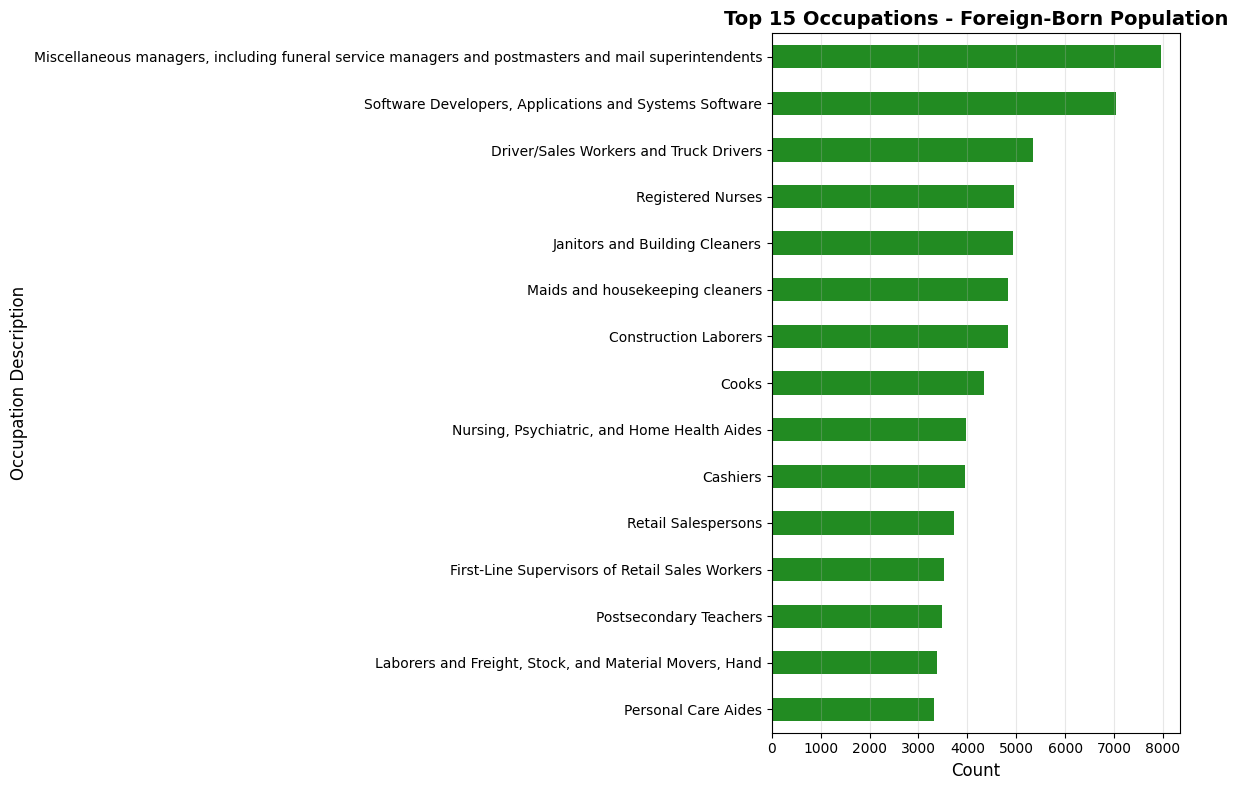


Total Foreign-Born Records: 281046

Top 15 Most Common Occupations (Foreign-Born, excluding NIU):
occupation_desc_detailed
Miscellaneous managers, including funeral service managers and postmasters and mail superintendents    7952
Software Developers, Applications and Systems Software                                                 7045
Driver/Sales Workers and Truck Drivers                                                                 5342
Registered Nurses                                                                                      4954
Janitors and Building Cleaners                                                                         4943
Maids and housekeeping cleaners                                                                        4839
Construction Laborers                                                                                  4834
Cooks                                                                                                  4350
Nursing, Psy

In [ ]:
foreign_born_df['occupation_desc_detailed'] = foreign_born_df['OCC2010'].apply(map_occupation_detailed)

# Get top 15 occupations (excluding NIU) and create bar chart
occupation_counts = foreign_born_df['occupation_desc_detailed'].value_counts()
occupation_counts_filtered = occupation_counts[occupation_counts.index != "NIU (Not in Universe)"]
top_15_occupations = occupation_counts_filtered.head(15).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
top_15_occupations.plot(kind='barh', ax=ax, color='forestgreen')

ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Occupation Description', fontsize=12)
ax.set_title('Top 15 Occupations - Foreign-Born Population', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTotal Foreign-Born Records: {len(foreign_born_df)}")
print(f"\nTop 15 Most Common Occupations (Foreign-Born, excluding NIU):")
print(occupation_counts_filtered.head(15))

Likely Legal

C:\Users\linds\AppData\Local\Temp\ipykernel_58772\622241793.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_likely_legal['occupation_desc_detailed'] = df_likely_legal['OCC2010'].apply(map_occupation_detailed)


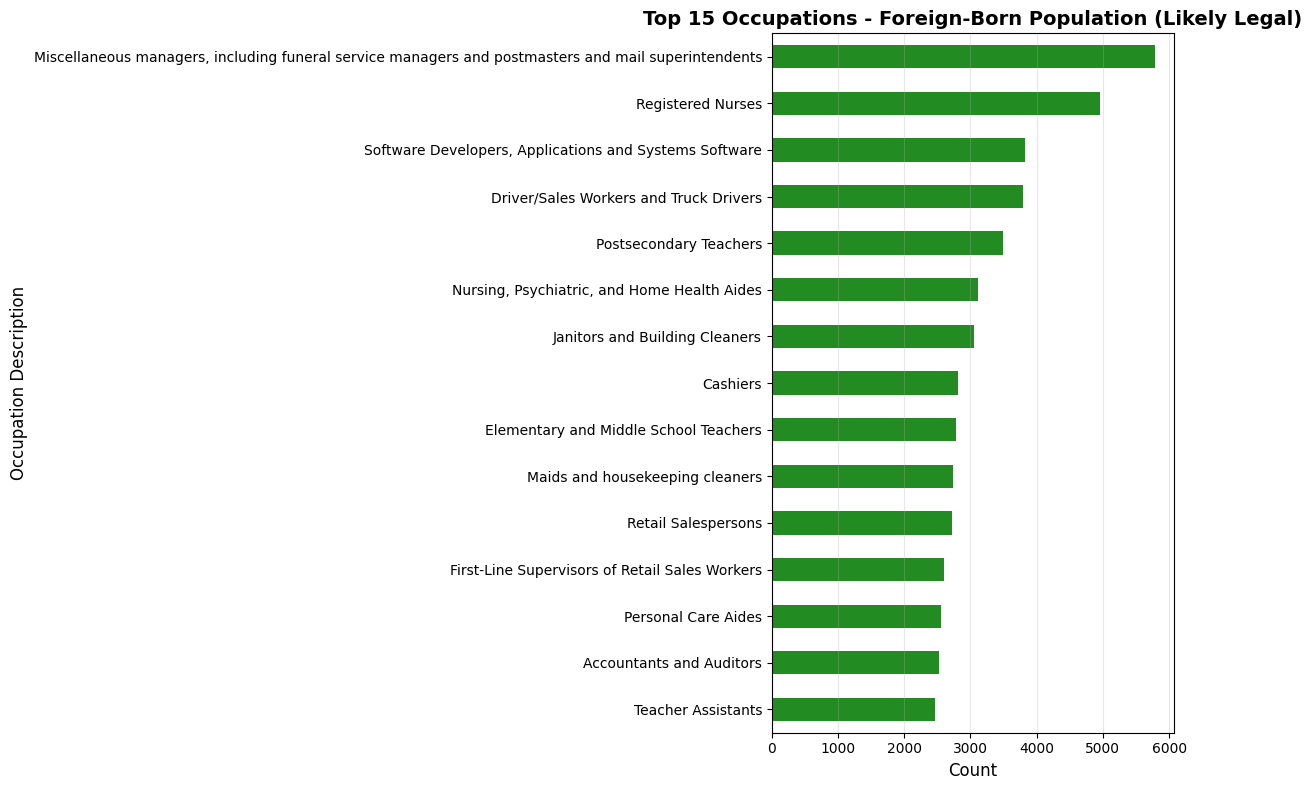


Total Foreign-Born Records: 205192

Top 15 Most Common Occupations (Foreign-Born, Likely Legal):
occupation_desc_detailed
Miscellaneous managers, including funeral service managers and postmasters and mail superintendents    5787
Registered Nurses                                                                                      4954
Software Developers, Applications and Systems Software                                                 3827
Driver/Sales Workers and Truck Drivers                                                                 3796
Postsecondary Teachers                                                                                 3486
Nursing, Psychiatric, and Home Health Aides                                                            3119
Janitors and Building Cleaners                                                                         3057
Cashiers                                                                                               2812
Elementary an

In [ ]:
df_likely_legal['occupation_desc_detailed'] = df_likely_legal['OCC2010'].apply(map_occupation_detailed)

# Get top 15 occupations (excluding NIU) and create bar chart
occupation_counts = df_likely_legal['occupation_desc_detailed'].value_counts()
occupation_counts_filtered = occupation_counts[occupation_counts.index != "NIU (Not in Universe)"]
top_15_occupations = occupation_counts_filtered.head(15).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
top_15_occupations.plot(kind='barh', ax=ax, color='forestgreen')

ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Occupation Description', fontsize=12)
ax.set_title('Top 15 Occupations - Foreign-Born Population (Likely Legal)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTotal Foreign-Born Records: {len(df_likely_legal)}")
print(f"\nTop 15 Most Common Occupations (Foreign-Born, Likely Legal):")
print(occupation_counts_filtered.head(15))

Likely Unauthorized

C:\Users\linds\AppData\Local\Temp\ipykernel_58772\110634776.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_likely_unauthorized['occupation_desc_detailed'] = df_likely_unauthorized['OCC2010'].apply(map_occupation_detailed)


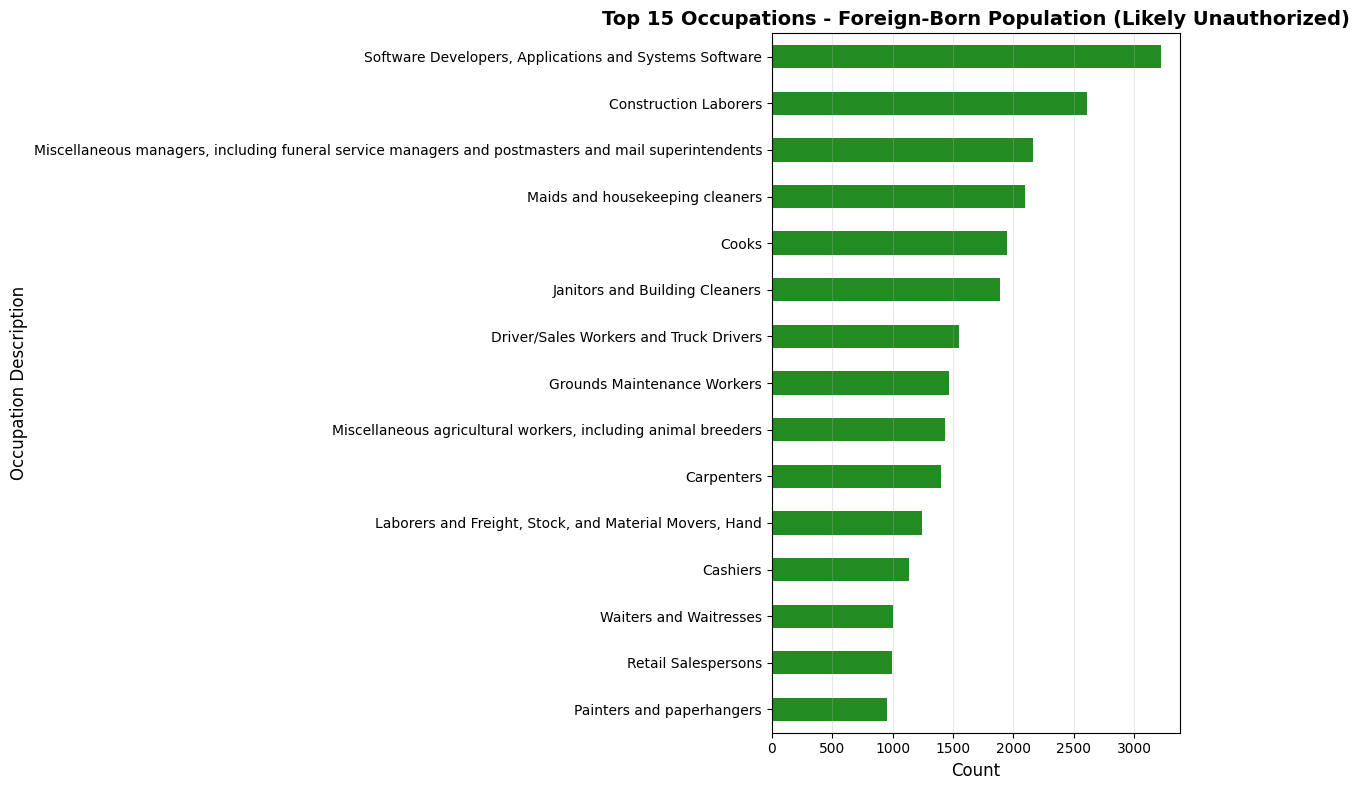


Total Foreign-Born Records: 75854

Top 15 Most Common Occupations (Foreign-Born, Likely Unauthorized):
occupation_desc_detailed
Software Developers, Applications and Systems Software                                                 3218
Construction Laborers                                                                                  2612
Miscellaneous managers, including funeral service managers and postmasters and mail superintendents    2165
Maids and housekeeping cleaners                                                                        2096
Cooks                                                                                                  1946
Janitors and Building Cleaners                                                                         1886
Driver/Sales Workers and Truck Drivers                                                                 1546
Grounds Maintenance Workers                                                                            1468
Miscell

In [ ]:
df_likely_unauthorized['occupation_desc_detailed'] = df_likely_unauthorized['OCC2010'].apply(map_occupation_detailed)

# Get top 15 occupations (excluding NIU) and create bar chart
occupation_counts = df_likely_unauthorized['occupation_desc_detailed'].value_counts()
occupation_counts_filtered = occupation_counts[occupation_counts.index != "NIU (Not in Universe)"]
top_15_occupations = occupation_counts_filtered.head(15).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
top_15_occupations.plot(kind='barh', ax=ax, color='forestgreen')

ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Occupation Description', fontsize=12)
ax.set_title('Top 15 Occupations - Foreign-Born Population (Likely Unauthorized)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTotal Foreign-Born Records: {len(df_likely_unauthorized)}")
print(f"\nTop 15 Most Common Occupations (Foreign-Born, Likely Unauthorized):")
print(occupation_counts_filtered.head(15))

# Occupational Distribution of H1B Visa Holders: Validation

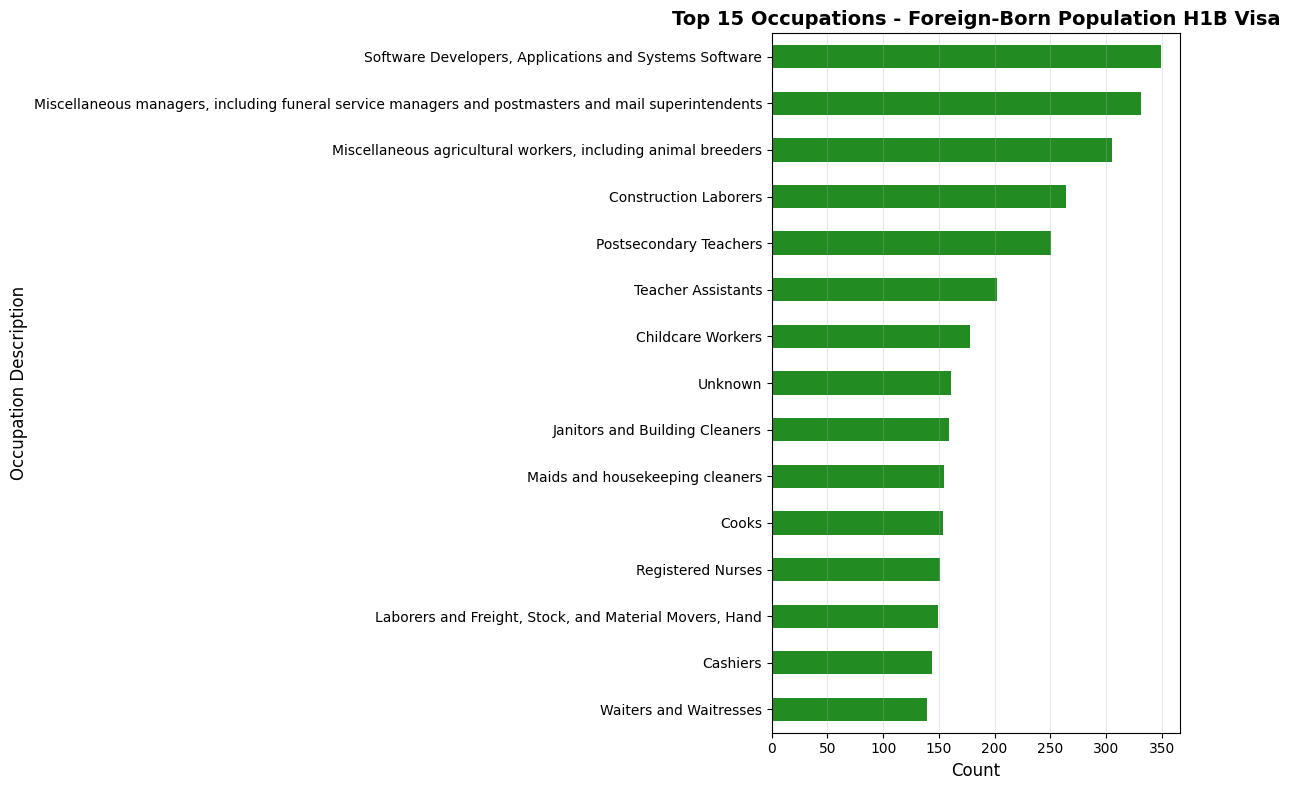


Total Foreign-Born Records: 11586

Top 15 Most Common Occupations H1B Visa:
occupation_desc_detailed
Software Developers, Applications and Systems Software                                                 349
Miscellaneous managers, including funeral service managers and postmasters and mail superintendents    331
Miscellaneous agricultural workers, including animal breeders                                          305
Construction Laborers                                                                                  264
Postsecondary Teachers                                                                                 251
Teacher Assistants                                                                                     202
Childcare Workers                                                                                      178
Unknown                                                                                                161
Janitors and Building Cleaners            

In [ ]:
df_h1b_likely_legal = foreign_born_df[h1b_likely_legal].copy()
df_h1b_likely_legal['occupation_desc_detailed'] = df_h1b_likely_legal['OCC2010'].apply(map_occupation_detailed)

# Get top 15 occupations (excluding NIU) and create bar chart
occupation_counts = df_h1b_likely_legal['occupation_desc_detailed'].value_counts()
occupation_counts_filtered = occupation_counts[occupation_counts.index != "NIU (Not in Universe)"]
top_15_occupations = occupation_counts_filtered.head(15).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
top_15_occupations.plot(kind='barh', ax=ax, color='forestgreen')

ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Occupation Description', fontsize=12)
ax.set_title('Top 15 Occupations - Foreign-Born Population H1B Visa', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTotal Foreign-Born Records: {len(df_h1b_likely_legal)}")
print(f"\nTop 15 Most Common Occupations H1B Visa:")
print(occupation_counts_filtered.head(15))

In [ ]:
import pandas as pd
h1b_df=pd.read_excel(r"C:\Users\linds\Downloads\Employer Information.xlsx")

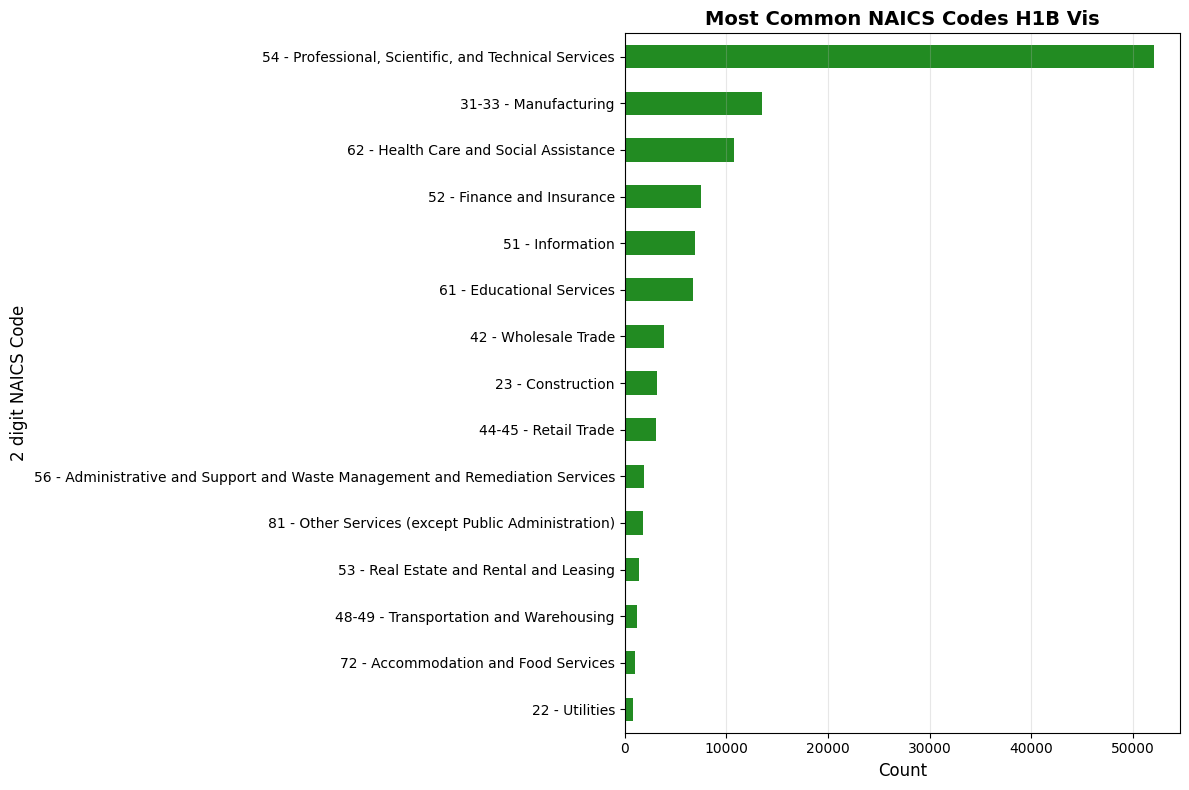


Most Common NAICS Codes H1B Visa: 124148

Top 20 Most Common NAICS Codes H1B Visa:
Industry (NAICS) Code
54 - Professional, Scientific, and Technical Services                            52046
31-33 - Manufacturing                                                            13515
62 - Health Care and Social Assistance                                           10757
52 - Finance and Insurance                                                        7507
51 - Information                                                                  6885
61 - Educational Services                                                         6770
42 - Wholesale Trade                                                              3823
23 - Construction                                                                 3216
44-45 - Retail Trade                                                              3038
56 - Administrative and Support and Waste Management and Remediation Services     1931
81 - Other Services (exc

In [ ]:
# Get top 15 occupations (excluding NIU) and create bar chart
import matplotlib.pyplot as plt
occupation_counts = h1b_df['Industry (NAICS) Code'].value_counts()
occupation_counts_filtered = occupation_counts[occupation_counts.index != "NIU (Not in Universe)"]
top_15_occupations = occupation_counts_filtered.head(15).sort_values(ascending=True)


fig, ax = plt.subplots(figsize=(12, 8))
top_15_occupations.plot(kind='barh', ax=ax, color='forestgreen')

ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('2 digit NAICS Code', fontsize=12)
ax.set_title('Most Common NAICS Codes H1B Vis', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMost Common NAICS Codes H1B Visa: {len(h1b_df)}")
print(f"\nTop 20 Most Common NAICS Codes H1B Visa:")
print(occupation_counts_filtered.head(20))


## U.S. unauthorized immigrant population by state (tile map)

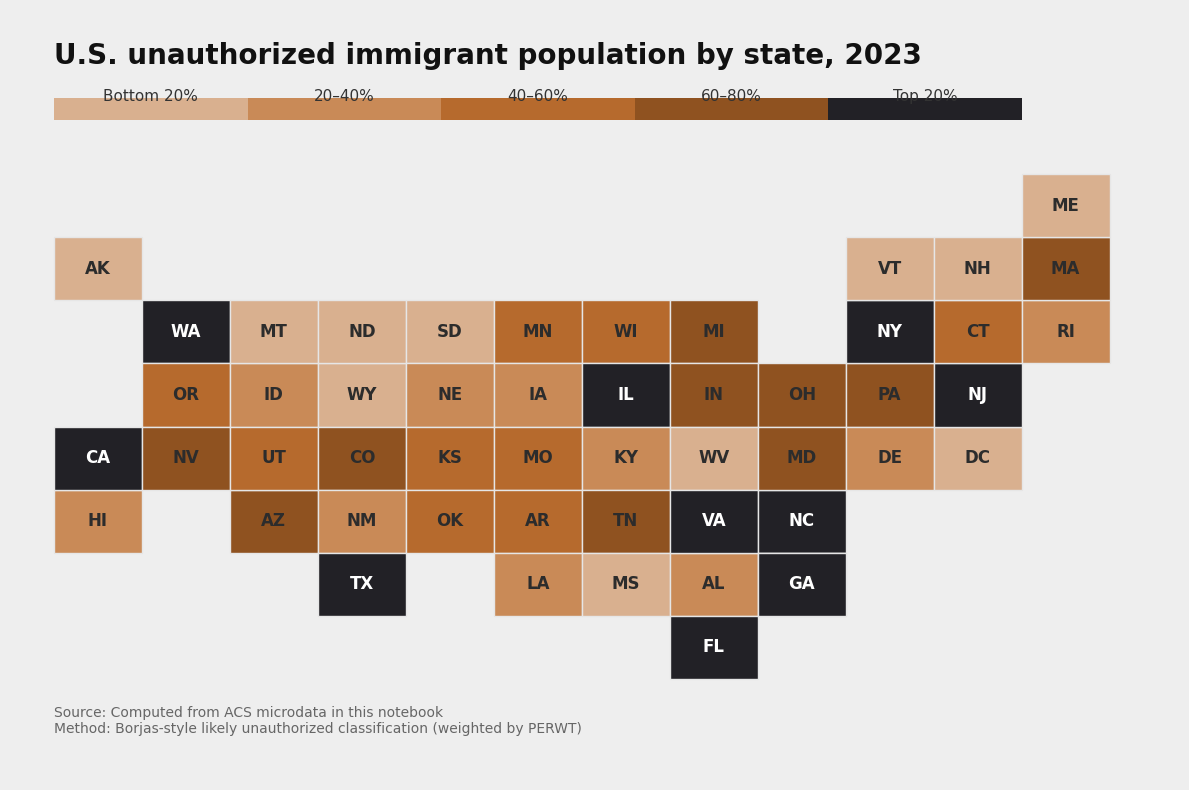

CA    413838
TX    333754
FL    188141
NY    129393
NJ     98151
IL     91018
GA     72860
WA     65190
NC     60267
VA     54433
dtype: int64

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# Build likely unauthorized weighted population by state from existing dataframe
unauth_df = foreign_born_df[~foreign_born_df['likely_legal']].copy()
unauth_df['PERWT_num'] = pd.to_numeric(unauth_df.get('PERWT', 0), errors='coerce').fillna(0)
state_counts = (
    unauth_df.groupby('STATEFIP', as_index=False)['PERWT_num']
    .sum()
    .rename(columns={'PERWT_num': 'weighted_count'})
)

# STATEFIP -> state abbreviation
statefip_to_abbr = {
    1: 'AL', 2: 'AK', 4: 'AZ', 5: 'AR', 6: 'CA', 8: 'CO', 9: 'CT', 10: 'DE', 11: 'DC',
    12: 'FL', 13: 'GA', 15: 'HI', 16: 'ID', 17: 'IL', 18: 'IN', 19: 'IA', 20: 'KS',
    21: 'KY', 22: 'LA', 23: 'ME', 24: 'MD', 25: 'MA', 26: 'MI', 27: 'MN', 28: 'MS',
    29: 'MO', 30: 'MT', 31: 'NE', 32: 'NV', 33: 'NH', 34: 'NJ', 35: 'NM', 36: 'NY',
    37: 'NC', 38: 'ND', 39: 'OH', 40: 'OK', 41: 'OR', 42: 'PA', 44: 'RI', 45: 'SC',
    46: 'SD', 47: 'TN', 48: 'TX', 49: 'UT', 50: 'VT', 51: 'VA', 53: 'WA', 54: 'WV',
    55: 'WI', 56: 'WY'
}
state_counts['state'] = state_counts['STATEFIP'].map(statefip_to_abbr)
state_counts = state_counts.dropna(subset=['state'])
state_to_count = dict(zip(state_counts['state'], state_counts['weighted_count']))

# 50-state + DC tile grid coordinates (column x, row y)
tile_pos = {
    'AK': (0, 1), 'HI': (0, 5),
    'WA': (1, 2), 'OR': (1, 3), 'CA': (0, 4),
    'ID': (2, 3), 'NV': (1, 4), 'AZ': (2, 5),
    'MT': (2, 2), 'WY': (3, 3), 'UT': (2, 4),
    'ND': (3, 2), 'SD': (4, 2), 'NE': (4, 3), 'CO': (3, 4), 'NM': (3, 5),
    'MN': (5, 2), 'IA': (5, 3), 'KS': (4, 4), 'OK': (4, 5), 'TX': (3, 6),
    'WI': (6, 2), 'IL': (6, 3), 'MO': (5, 4), 'AR': (5, 5), 'LA': (5, 6),
    'MI': (7, 2), 'IN': (7, 3), 'KY': (6, 4), 'TN': (6, 5), 'MS': (6, 6), 'AL': (7, 6),
    'OH': (8, 3), 'WV': (7, 4), 'VA': (7, 5), 'NC': (8, 5), 'SC': (8, 6), 'GA': (8, 6), 'FL': (7, 7),
    'PA': (9, 3), 'MD': (8, 4), 'DE': (9, 4), 'DC': (10, 4),
    'NY': (9, 2), 'NJ': (10, 3), 'CT': (10, 2), 'RI': (11, 2),
    'VT': (9, 1), 'NH': (10, 1), 'MA': (11, 1), 'ME': (11, 0)
}

# Remove duplicate Georgia/Alabama conflict by correcting GA tile to match common grid layout
tile_pos['GA'] = (8, 6)

# Compute quintile breakpoints from the actual weighted state totals
counts_arr = np.array(list(state_to_count.values()))
quintile_edges = np.percentile(counts_arr, [0, 20, 40, 60, 80, 100])
quintile_edges[-1] *= 1.001  # nudge upper bound so max value is included

labels = ['Bottom 20%', '20–40%', '40–60%', '60–80%', 'Top 20%']
colors = ['#d9b08f', '#c98a57', '#b66a2d', '#8f5220', '#222126']

# Assign each state to its quintile bin
state_bin = {}
for st, val in state_to_count.items():
    idx = pd.cut([val], bins=quintile_edges, labels=False, include_lowest=True)[0]
    if pd.isna(idx):
        idx = len(colors) - 1
    state_bin[st] = int(idx)

# Figure setup
fig, ax = plt.subplots(figsize=(12, 8), facecolor='#eeeeee')
ax.set_facecolor('#eeeeee')

# Draw legend manually for layout control
legend_x0 = 0
legend_y = -1.2
box_w = 2.2
box_h = 0.35
for i, (lab, col) in enumerate(zip(labels, colors)):
    x = legend_x0 + i * box_w
    rect = patches.Rectangle((x, legend_y), box_w, box_h, facecolor=col, edgecolor='none')
    ax.add_patch(rect)
    ax.text(x + box_w / 2, legend_y - 0.15, lab, ha='center', va='top', fontsize=11, color='#333333')

# Draw tiles
for st, (x, y) in tile_pos.items():
    idx = state_bin.get(st, 0)
    fill = colors[idx]

    rect = patches.Rectangle((x, y), 1, 1, facecolor=fill, edgecolor='#e6e6e6', linewidth=1.0)
    ax.add_patch(rect)

    text_color = 'white' if mcolors.rgb_to_hsv(mcolors.to_rgb(fill))[2] < 0.5 else '#2c2c2c'
    ax.text(x + 0.5, y + 0.5, st, ha='center', va='center', fontsize=12, fontweight='bold', color=text_color)

# Title and source text
ax.text(0, -2.1, 'U.S. unauthorized immigrant population by state',
        ha='left', va='top', fontsize=20, fontweight='bold', color='#111111')
ax.text(0, 8.9,
        'Source: Computed from ACS microdata in this notebook\nMethod: Borjas-style likely unauthorized classification (weighted)',
        ha='left', va='bottom', fontsize=10, color='#666666')

# Frame/limits and clean axes
ax.set_xlim(-0.5, 12.8)
ax.set_ylim(9.6, -2.6)
ax.axis('off')

plt.tight_layout()
plt.show()

# Optional quick table of top states (weighted)
pd.Series(state_to_count).sort_values(ascending=False).head(10).round(0).astype(int)


In [ ]:
# Debug check: compare unauthorized by state unweighted vs PERWT-weighted
_debug_unauth = foreign_born_df[~foreign_born_df['likely_legal']].copy()
_debug_unauth['PERWT_num'] = pd.to_numeric(_debug_unauth.get('PERWT', 0), errors='coerce').fillna(0)

_statefip_to_abbr = {
    1: 'AL', 2: 'AK', 4: 'AZ', 5: 'AR', 6: 'CA', 8: 'CO', 9: 'CT', 10: 'DE', 11: 'DC',
    12: 'FL', 13: 'GA', 15: 'HI', 16: 'ID', 17: 'IL', 18: 'IN', 19: 'IA', 20: 'KS',
    21: 'KY', 22: 'LA', 23: 'ME', 24: 'MD', 25: 'MA', 26: 'MI', 27: 'MN', 28: 'MS',
    29: 'MO', 30: 'MT', 31: 'NE', 32: 'NV', 33: 'NH', 34: 'NJ', 35: 'NM', 36: 'NY',
    37: 'NC', 38: 'ND', 39: 'OH', 40: 'OK', 41: 'OR', 42: 'PA', 44: 'RI', 45: 'SC',
    46: 'SD', 47: 'TN', 48: 'TX', 49: 'UT', 50: 'VT', 51: 'VA', 53: 'WA', 54: 'WV',
    55: 'WI', 56: 'WY'
}

_unweighted = _debug_unauth.groupby('STATEFIP').size().rename('unweighted').reset_index()
_weighted = _debug_unauth.groupby('STATEFIP', as_index=False)['PERWT_num'].sum().rename(columns={'PERWT_num': 'weighted'})
_cmp = _unweighted.merge(_weighted, on='STATEFIP', how='outer').fillna(0)
_cmp['state'] = _cmp['STATEFIP'].map(_statefip_to_abbr)
_cmp = _cmp.dropna(subset=['state'])

print('Top 10 unweighted:')
print(_cmp.sort_values('unweighted', ascending=False)[['state', 'unweighted']].head(10).to_string(index=False))
print('\nTop 10 weighted (PERWT):')
print(_cmp.sort_values('weighted', ascending=False)[['state', 'weighted']].head(10).to_string(index=False))

Top 10 unweighted:
state  unweighted
   CA       16890
   TX       11275
   FL        6384
   NY        4757
   NJ        3649
   IL        3056
   WA        2452
   GA        2420
   NC        2052
   VA        1811

Top 10 weighted (PERWT):
state  weighted
   CA  413838.0
   TX  333754.0
   FL  188141.0
   NY  129393.0
   NJ   98151.0
   IL   91018.0
   GA   72860.0
   WA   65190.0
   NC   60267.0
   VA   54433.0
